## 3. Intégration temporelle et Visualisation Graphique de l'ENMO

### Raisonnement :
Ici nous appliquons une **intégration temporelle par époque** sur trois durées différentes : **10 secondes, 30 secondes et 60 secondes**. 

L'intégration consiste à sommer les valeurs d'ENMO sur chaque fenêtre de temps et à exprimer le résultat en $g\cdot\text{min}. Cela permet de lisser le signal, de réduire le bruit de mesure et d'observer l'impact de la résolution temporelle sur l'analyse.

### Fonction d'intégration par époque :

La fonction ci-dessous découpe le signal en fonction de la fréquence d'échantillonnage ($f_s$) et de la durée de l'époque (10 s, 30 s ou 60 s) choisie, puis regroupe les échantillons par blocs temporels pour en sommer l'intensité.

### Description détaillée de la fonction de visualisation (`plot_enmo_analysis`)

 Son exécution se décompose en plusieurs étapes clés :

* **1. Calcul et récupération de l'ENMO intégrée** :
La fonction commence par appeler la fonction de calcul de l'équipe (`calculate_integrated_enmo`) pour agréger les valeurs d'ENMO sur la fenêtre temporelle choisie, obtenant ainsi l'aire sous la courbe par époque (exprimée en $g\cdot\text{min}$).
* **2. Préparation des axes temporels en minutes** :
* `time_min = df["t"] / 60.0` convertit le temps brut en secondes en minutes pour l'axe horizontal du graphique inférieur.
* `time_epoch` calcule le positionnement temporel des barres en fonction de la durée de l'époque (`epoch_min`).


* **3. Initialisation d'une figure à deux panneaux** :
À l'aide de `plt.subplots(2, 1, sharex=True, dpi=100)`, on crée une figure verticale contenant deux sous-graphes (`ax[0]` et `ax[1]`) qui partagent exactement le même axe des abscisses pour faciliter la comparaison visuelle.
* **4. Tracé du sous-graphe supérieur (Diagramme en barres)** :
* `ax[0].bar(...)` dessine les valeurs de l'ENMO intégrée sous forme de barres grises (`color="darkgray"`).
* L'utilisation de `align="edge"` et d'une largeur de barre légèrement réduite (`width=epoch_min * 0.95`) permet d'espacer proprement chaque période.
* Le titre du graphique s'adapte automatiquement à la durée de l'époque testée (`f"ENMO integrated over {epoch:.1f} s intervals"`).


* **5. Tracé du sous-graphe inférieur (Courbe continue du signal brut)** :
* `ax[1].plot(...)` trace l'ENMO brute au fil du temps en bleu (`#1f77b4`).
* Un paramètre de transparence (`alpha=0.55`) et une faible épaisseur de ligne (`linewidth=0.8`) sont appliqués pour que les variations rapides et les pics d'activité restent parfaitement lisibles.


* **6. Mise en page et retour des résultats** :
* `plt.tight_layout()` ajuste automatiquement l'espacement des éléments pour éviter toute superposition visuelle.
* `plt.show()` affiche la figure finale à l'écran, et la fonction retourne la série de données `integrated_enmo`.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement des données et calcul de la fréquence
df = pd.read_csv("0_z.csv", comment="#")
dt = df["t"].iloc[1] - df["t"].iloc[0]
fs = 1 / dt

# 2. Calcul de l'ENMO brute
df["enmo"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2) - 1

# 3. Fonction de l'ENMO intégrée (provenant de l'équipe)
def calculate_integrated_enmo(df, epoch, fs):
    samples = int(fs * epoch)
    integrated_enmo = (
        df["enmo"]
        .groupby(df.index // samples)
        .sum()
        * epoch / 60
    )
    return integrated_enmo

In [29]:
# 1. Définition de la fonction pour tracer les graphiques conformément aux attentes
def plot_enmo_analysis(df, epoch, fs):
    """
    Génère la figure à deux sous-graphes :
    - En haut : l'ENMO intégrée (g.min) en diagramme en barres grises.
    - En bas : l'ENMO brute au cours du temps (en minutes).
    """
    # Utilisation de la fonction de l'ENMO intégrée
    integrated_enmo = calculate_integrated_enmo(df, epoch, fs)

    time_min = df["t"] / 60.0
    epoch_min = epoch / 60.0
    time_epoch = np.arange(len(integrated_enmo)) * epoch_min

    fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True, dpi=100)

    # Graphique du haut (Barres)
    ax[0].bar(
        time_epoch,
        integrated_enmo,
        width=epoch_min * 0.95,
        align="edge",
        color="darkgray",
    )
    ax[0].set_title(f"ENMO integrated over {epoch:.1f} s intervals", fontsize=11)
    ax[0].set_ylabel("Integrated ENMO (g.min)", fontsize=9)
    ax[0].tick_params(axis="both", which="major", labelsize=9)

    # Graphique du bas (Courbe continue)
    ax[1].plot(time_min, df["enmo"], color="#1f77b4", alpha=0.55, linewidth=0.8)
    ax[1].set_title("ENMO over Time", fontsize=11)
    ax[1].set_xlabel("Time (minutes)", fontsize=9)
    ax[1].set_ylabel("ENMO (g)", fontsize=9)
    ax[1].tick_params(axis="both", which="major", labelsize=9)
    ax[1].set_xlim(-0.3, max(7.2, time_min.max() + 0.2))

    plt.tight_layout()
    plt.show()

    return integrated_enmo


### Fonction de tracé des graphiques comparatifs :
Pour répondre aux critères visuels du sujet, nous concevons une fonction modulaire qui génère une figure à **deux sous-graphes superposés** partageant le même axe horizontal (le temps en minutes):

1. **Le Diagramme en barres** : Affiche l'ENMO intégrée en $g\cdot\text{min}$ sous forme de barres grises (`darkgray`), 
2. **La Courbe continue** : Affiche l'ENMO brute au cours du temps en bleu (`#1f77b4`) 

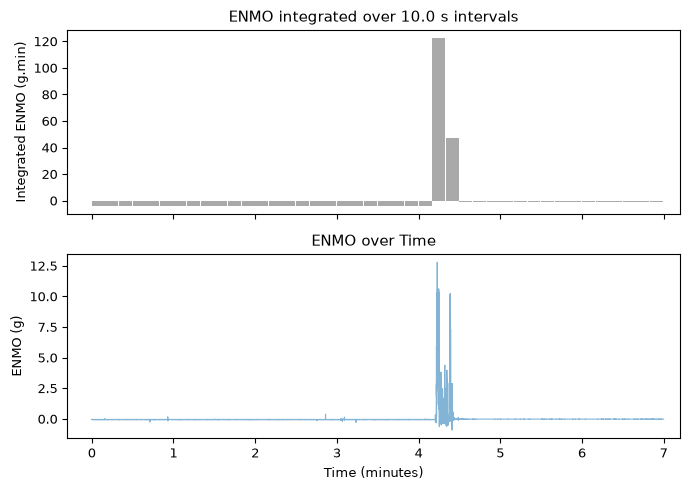

In [30]:
integrated_10s = plot_enmo_analysis(df, 10.0, fs)

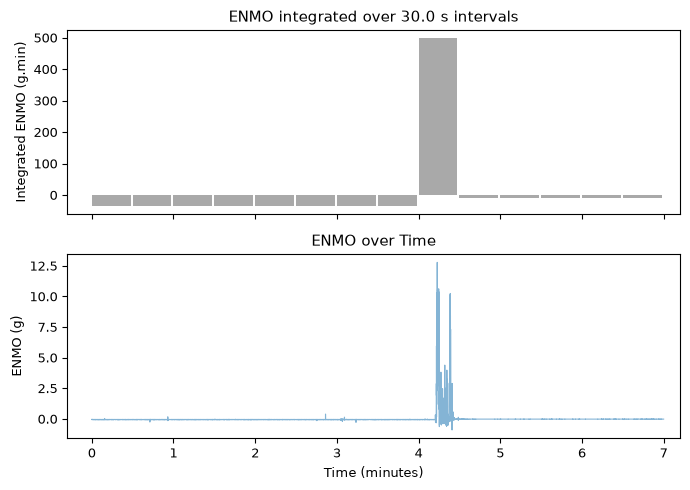

In [31]:
integrated_30s = plot_enmo_analysis(df, 30.0, fs)

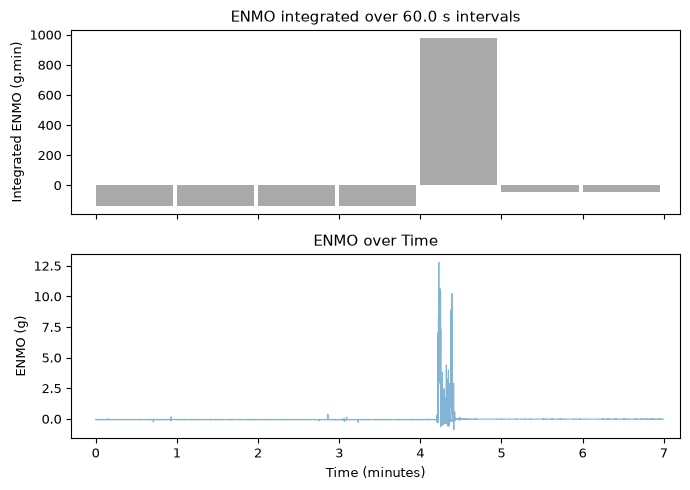

In [32]:
integrated_60s = plot_enmo_analysis(df, 60.0, fs)